In [3]:
import pandas as pd
df = pd.read_csv("../Data/mmm_weekly_data.csv")
df.head()

,week,tv_spend,search_spend,social_spend,email_spend,promo_flag,sales
0,1/1/2024,49470,13813,6497,1820,0,130777
1,1/8/2024,43756,18185,8839,2098,0,161228
2,1/15/2024,50829,15132,249,1736,0,147638
3,1/22/2024,58707,19279,6234,2366,0,165572
4,1/29/2024,42893,15518,8318,2236,0,160711


In [4]:
df.shape

(130, 7)

In [5]:
def apply_adstock(spend_series, decay_rate):
    adstocked = spend_series.copy()
    for t in range(1, len(spend_series)):
        adstocked[t] = spend_series[t] + decay_rate * adstocked[t - 1]
    return adstocked

In [6]:
df["tv_adstocked"] = apply_adstock(df["tv_spend"], 0.7)
df[["week", "tv_spend", "tv_adstocked"]].head(10)

C:\Users\ramee\AppData\Local\Temp\ipykernel_12528\2772106243.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '105698.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  adstocked[t] = spend_series[t] + decay_rate * adstocked[t - 1]


,week,tv_spend,tv_adstocked
0,1/1/2024,49470,49470.000000
1,1/8/2024,43756,78385.000000
2,1/15/2024,50829,105698.500000
3,1/22/2024,58707,132695.950000
4,1/29/2024,42893,135780.165000
5,2/5/2024,42893,137939.115500
6,2/12/2024,59213,155770.380850
7,2/19/2024,51907,160946.266595
8,2/26/2024,40775,153437.386616
9,3/4/2024,49883,157289.170632


In [7]:
df["search_adstocked"] = apply_adstock(df["search_spend"], 0.15)
df["social_adstocked"] = apply_adstock(df["social_spend"], 0.4)
df["email_adstocked"] = apply_adstock(df["email_spend"], 0.05)

df[["week", "search_spend", "search_adstocked",
    "social_spend", "social_adstocked",
    "email_spend", "email_adstocked"]].head(10)

C:\Users\ramee\AppData\Local\Temp\ipykernel_12528\2772106243.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '20256.95' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  adstocked[t] = spend_series[t] + decay_rate * adstocked[t - 1]
C:\Users\ramee\AppData\Local\Temp\ipykernel_12528\2772106243.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '11437.8' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  adstocked[t] = spend_series[t] + decay_rate * adstocked[t - 1]
C:\Users\ramee\AppData\Local\Temp\ipykernel_12528\2772106243.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1845.45' has dtype incompatible with int64, please explicitly cast to a compatible dtype 

,week,search_spend,search_adstocked,social_spend,social_adstocked,email_spend,email_adstocked
0,1/1/2024,13813,13813.000000,6497,6497.000000,1820,1820.000000
1,1/8/2024,18185,20256.950000,8839,11437.800000,2098,2189.000000
2,1/15/2024,15132,18170.542500,249,4824.120000,1736,1845.450000
3,1/22/2024,19279,22004.581375,6234,8163.648000,2366,2458.272500
4,1/29/2024,15518,18818.687206,8318,11583.459200,2236,2358.913625
5,2/5/2024,22185,25007.803081,5631,10264.383680,1906,2023.945681
6,2/12/2024,15885,19636.170462,13408,17513.753472,1657,1758.197284
7,2/19/2024,17130,20075.425569,5139,12144.501389,2271,2358.909864
8,2/26/2024,20196,23207.313835,7812,12669.800556,1977,2094.945493
9,3/4/2024,14677,18158.097075,9353,14420.920222,2248,2352.747275


In [8]:
def apply_saturation(adstocked_series, half_sat):
    return adstocked_series / (adstocked_series + half_sat)

tv_half_sat = df["tv_adstocked"].median()
search_half_sat = df["search_adstocked"].median()
social_half_sat = df["social_adstocked"].median()
email_half_sat = df["email_adstocked"].median()

df["tv_saturated"] = apply_saturation(df["tv_adstocked"], tv_half_sat)
df["search_saturated"] = apply_saturation(df["search_adstocked"], search_half_sat)
df["social_saturated"] = apply_saturation(df["social_adstocked"], social_half_sat)
df["email_saturated"] = apply_saturation(df["email_adstocked"], email_half_sat)

df[["tv_adstocked", "tv_saturated", "search_adstocked", "search_saturated"]].head(10)

,tv_adstocked,tv_saturated,search_adstocked,search_saturated
0,49470.000000,0.244875,13813.000000,0.387317
1,78385.000000,0.339423,20256.950000,0.481080
2,105698.500000,0.409288,18170.542500,0.454027
3,132695.950000,0.465196,22004.581375,0.501759
4,135780.165000,0.470917,18818.687206,0.462728
5,137939.115500,0.474849,25007.803081,0.533692
6,155770.380850,0.505220,19636.170462,0.473315
7,160946.266595,0.513389,20075.425569,0.478833
8,153437.386616,0.501448,23207.313835,0.515059
9,157289.170632,0.507646,18158.097075,0.453857


In [9]:
df["trend"] = range(len(df))

In [10]:
from sklearn.linear_model import LinearRegression

feature_cols = ["tv_saturated", "search_saturated", "social_saturated", "email_saturated", "promo_flag", "trend"]
X = df[feature_cols]
y = df["sales"]

model = LinearRegression()
model.fit(X, y)

for name, coef in zip(feature_cols, model.coef_):
    print(f"{name}: {coef:.2f}")

print(f"intercept (baseline sales): {model.intercept_:.2f}")

tv_saturated: 30407.07
search_saturated: 69179.49
social_saturated: 82739.30
email_saturated: 22419.88
promo_flag: 7004.90
trend: 264.70
intercept (baseline sales): 69421.06


In [11]:
import pandas as pd

ground_truth = pd.read_csv("../Data/mmm_ground_truth.csv")

df["tv_est_contribution"] = model.coef_[0] * df["tv_saturated"]
df["search_est_contribution"] = model.coef_[1] * df["search_saturated"]
df["social_est_contribution"] = model.coef_[2] * df["social_saturated"]
df["email_est_contribution"] = model.coef_[3] * df["email_saturated"]

comparison = pd.DataFrame({
    "channel": ["tv", "search", "social", "email"],
    "estimated_avg_contribution": [
        df["tv_est_contribution"].mean(),
        df["search_est_contribution"].mean(),
        df["social_est_contribution"].mean(),
        df["email_est_contribution"].mean(),
    ],
    "true_avg_contribution": [
        ground_truth["tv_contribution"].mean(),
        ground_truth["search_contribution"].mean(),
        ground_truth["social_contribution"].mean(),
        ground_truth["email_contribution"].mean(),
    ],
})
comparison

,channel,estimated_avg_contribution,true_avg_contribution
0,tv,15302.000381,39528.000000
1,search,34697.026321,23741.407692
2,social,41583.364132,23184.700000
3,email,11199.558495,4650.830769


In [12]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1000)
ridge_model.fit(X, y)

for name, coef in zip(feature_cols, ridge_model.coef_):
    print(f"{name}: {coef:.2f}")
print(f"intercept: {ridge_model.intercept_:.2f}")

tv_saturated: 25.75
search_saturated: 29.37
social_saturated: 55.67
email_saturated: 0.82
promo_flag: 28.84
trend: 293.45
intercept: 170560.58


In [13]:
from sklearn.linear_model import RidgeCV
import numpy as np

alphas_to_try = np.logspace(-2, 4, 50)  # tests 0.01 up to 10,000
ridge_cv_model = RidgeCV(alphas=alphas_to_try)
ridge_cv_model.fit(X, y)

print(f"best alpha chosen: {ridge_cv_model.alpha_:.4f}")
for name, coef in zip(feature_cols, ridge_cv_model.coef_):
    print(f"{name}: {coef:.2f}")
print(f"intercept: {ridge_cv_model.intercept_:.2f}")

best alpha chosen: 0.0409
tv_saturated: 30869.95
search_saturated: 61760.38
social_saturated: 77767.71
email_saturated: 14627.09
promo_flag: 6892.49
trend: 266.18
intercept: 79209.41


In [14]:
df["tv_est_ridge"] = ridge_cv_model.coef_[0] * df["tv_saturated"]
df["search_est_ridge"] = ridge_cv_model.coef_[1] * df["search_saturated"]
df["social_est_ridge"] = ridge_cv_model.coef_[2] * df["social_saturated"]
df["email_est_ridge"] = ridge_cv_model.coef_[3] * df["email_saturated"]

comparison_ridge = pd.DataFrame({
    "channel": ["tv", "search", "social", "email"],
    "ridge_estimated": [
        df["tv_est_ridge"].mean(),
        df["search_est_ridge"].mean(),
        df["social_est_ridge"].mean(),
        df["email_est_ridge"].mean(),
    ],
    "true_avg_contribution": [
        ground_truth["tv_contribution"].mean(),
        ground_truth["search_contribution"].mean(),
        ground_truth["social_contribution"].mean(),
        ground_truth["email_contribution"].mean(),
    ],
})
comparison_ridge

,channel,ridge_estimated,true_avg_contribution
0,tv,15534.937096,39528.000000
1,search,30975.962585,23741.407692
2,social,39084.726826,23184.700000
3,email,7306.770839,4650.830769


In [15]:
import numpy as np

df["week"] = pd.to_datetime(df["week"])
df["week_of_year"] = df["week"].dt.isocalendar().week.astype(int)

df["seasonality_sin"] = np.sin(2 * np.pi * df["week_of_year"] / 52)
df["seasonality_cos"] = np.cos(2 * np.pi * df["week_of_year"] / 52)

In [16]:
feature_cols_v2 = ["tv_saturated", "search_saturated", "social_saturated", "email_saturated",
                    "promo_flag", "trend", "seasonality_sin", "seasonality_cos"]
X_v2 = df[feature_cols_v2]

ridge_cv_v2 = RidgeCV(alphas=alphas_to_try)
ridge_cv_v2.fit(X_v2, y)

print(f"best alpha: {ridge_cv_v2.alpha_:.4f}")
for name, coef in zip(feature_cols_v2, ridge_cv_v2.coef_):
    print(f"{name}: {coef:.2f}")

best alpha: 0.0543
tv_saturated: 30026.04
search_saturated: 49466.73
social_saturated: 78451.84
email_saturated: 9291.94
promo_flag: 10014.72
trend: 268.87
seasonality_sin: -3242.72
seasonality_cos: 1924.20


In [17]:
df["tv_est_v2"] = ridge_cv_v2.coef_[0] * df["tv_saturated"]
df["search_est_v2"] = ridge_cv_v2.coef_[1] * df["search_saturated"]
df["social_est_v2"] = ridge_cv_v2.coef_[2] * df["social_saturated"]
df["email_est_v2"] = ridge_cv_v2.coef_[3] * df["email_saturated"]

comparison_v2 = pd.DataFrame({
    "channel": ["tv", "search", "social", "email"],
    "v2_estimated": [
        df["tv_est_v2"].mean(),
        df["search_est_v2"].mean(),
        df["social_est_v2"].mean(),
        df["email_est_v2"].mean(),
    ],
    "true_avg_contribution": [
        ground_truth["tv_contribution"].mean(),
        ground_truth["search_contribution"].mean(),
        ground_truth["social_contribution"].mean(),
        ground_truth["email_contribution"].mean(),
    ],
})
comparison_v2

,channel,v2_estimated,true_avg_contribution
0,tv,15110.249681,39528.000000
1,search,24810.075711,23741.407692
2,social,39428.558552,23184.700000
3,email,4641.665147,4650.830769


In [18]:
df[["tv_saturated", "search_saturated", "social_saturated", "email_saturated"]].corr()

,tv_saturated,search_saturated,social_saturated,email_saturated
tv_saturated,1.000000,0.501904,0.207806,-0.143312
search_saturated,0.501904,1.000000,0.042977,-0.008887
social_saturated,0.207806,0.042977,1.000000,-0.030017
email_saturated,-0.143312,-0.008887,-0.030017,1.000000


In [19]:
from scipy.optimize import minimize

def model_error(half_sats):
    tv_hs, search_hs, social_hs, email_hs = half_sats

    tv_sat = apply_saturation(df["tv_adstocked"], tv_hs)
    search_sat = apply_saturation(df["search_adstocked"], search_hs)
    social_sat = apply_saturation(df["social_adstocked"], social_hs)
    email_sat = apply_saturation(df["email_adstocked"], email_hs)

    X_temp = pd.DataFrame({
        "tv_saturated": tv_sat,
        "search_saturated": search_sat,
        "social_saturated": social_sat,
        "email_saturated": email_sat,
        "promo_flag": df["promo_flag"],
        "trend": df["trend"],
        "seasonality_sin": df["seasonality_sin"],
        "seasonality_cos": df["seasonality_cos"],
    })

    temp_model = Ridge(alpha=1.0)
    temp_model.fit(X_temp, y)
    predictions = temp_model.predict(X_temp)
    error = ((y - predictions) ** 2).sum()
    return error

In [20]:
starting_guess = [tv_half_sat, search_half_sat, social_half_sat, email_half_sat]

result = minimize(model_error, starting_guess, method="Nelder-Mead")

tv_hs_best, search_hs_best, social_hs_best, email_hs_best = result.x
print("Best half_sat values found:")
print(f"tv: {tv_hs_best:.2f}, search: {search_hs_best:.2f}, social: {social_hs_best:.2f}, email: {email_hs_best:.2f}")

Best half_sat values found:
tv: 120290.19, search: 26521.46, social: 15907.46, email: 1836.03


In [21]:
df["tv_saturated_v2"] = apply_saturation(df["tv_adstocked"], tv_hs_best)
df["search_saturated_v2"] = apply_saturation(df["search_adstocked"], search_hs_best)
df["social_saturated_v2"] = apply_saturation(df["social_adstocked"], social_hs_best)
df["email_saturated_v2"] = apply_saturation(df["email_adstocked"], email_hs_best)

feature_cols_v3 = ["tv_saturated_v2", "search_saturated_v2", "social_saturated_v2", "email_saturated_v2",
                    "promo_flag", "trend", "seasonality_sin", "seasonality_cos"]
X_v3 = df[feature_cols_v3]

ridge_v3 = RidgeCV(alphas=alphas_to_try)
ridge_v3.fit(X_v3, y)

for name, coef in zip(feature_cols_v3, ridge_v3.coef_):
    print(f"{name}: {coef:.2f}")

tv_saturated_v2: 30752.99
search_saturated_v2: 48884.21
social_saturated_v2: 78264.12
email_saturated_v2: 9456.34
promo_flag: 10016.63
trend: 268.73
seasonality_sin: -3247.18
seasonality_cos: 1917.64


In [22]:
df["tv_est_v3"] = ridge_v3.coef_[0] * df["tv_saturated_v2"]
df["search_est_v3"] = ridge_v3.coef_[1] * df["search_saturated_v2"]
df["social_est_v3"] = ridge_v3.coef_[2] * df["social_saturated_v2"]
df["email_est_v3"] = ridge_v3.coef_[3] * df["email_saturated_v2"]

comparison_v3 = pd.DataFrame({
    "channel": ["tv", "search", "social", "email"],
    "v3_estimated": [
        df["tv_est_v3"].mean(),
        df["search_est_v3"].mean(),
        df["social_est_v3"].mean(),
        df["email_est_v3"].mean(),
    ],
    "true_avg_contribution": [
        ground_truth["tv_contribution"].mean(),
        ground_truth["search_contribution"].mean(),
        ground_truth["social_contribution"].mean(),
        ground_truth["email_contribution"].mean(),
    ],
})
comparison_v3

,channel,v3_estimated,true_avg_contribution
0,tv,17276.536430,39528.000000
1,search,22182.107026,23741.407692
2,social,38755.361309,23184.700000
3,email,5027.279808,4650.830769


In [23]:
TRUE_SATURATION = {
    "tv": {"ceiling": 55000, "half_sat": 60000},
    "search": {"ceiling": 40000, "half_sat": 15000},
    "social": {"ceiling": 60000, "half_sat": 25000},
    "email": {"ceiling": 8000, "half_sat": 1500},
}

df["tv_saturated_true"] = apply_saturation(df["tv_adstocked"], TRUE_SATURATION["tv"]["half_sat"])
df["search_saturated_true"] = apply_saturation(df["search_adstocked"], TRUE_SATURATION["search"]["half_sat"])
df["social_saturated_true"] = apply_saturation(df["social_adstocked"], TRUE_SATURATION["social"]["half_sat"])
df["email_saturated_true"] = apply_saturation(df["email_adstocked"], TRUE_SATURATION["email"]["half_sat"])

feature_cols_true = ["tv_saturated_true", "search_saturated_true", "social_saturated_true", "email_saturated_true",
                      "promo_flag", "trend", "seasonality_sin", "seasonality_cos"]
X_true = df[feature_cols_true]

ridge_true = RidgeCV(alphas=alphas_to_try)
ridge_true.fit(X_true, y)

df["tv_est_true"] = ridge_true.coef_[0] * df["tv_saturated_true"]
df["search_est_true"] = ridge_true.coef_[1] * df["search_saturated_true"]
df["social_est_true"] = ridge_true.coef_[2] * df["social_saturated_true"]
df["email_est_true"] = ridge_true.coef_[3] * df["email_saturated_true"]

comparison_true = pd.DataFrame({
    "channel": ["tv", "search", "social", "email"],
    "estimated_with_true_saturation": [
        df["tv_est_true"].mean(), df["search_est_true"].mean(),
        df["social_est_true"].mean(), df["email_est_true"].mean(),
    ],
    "true_avg_contribution": [
        ground_truth["tv_contribution"].mean(), ground_truth["search_contribution"].mean(),
        ground_truth["social_contribution"].mean(), ground_truth["email_contribution"].mean(),
    ],
})
comparison_true

,channel,estimated_with_true_saturation,true_avg_contribution
0,tv,28845.149883,39528.000000
1,search,32305.789826,23741.407692
2,social,31517.893117,23184.700000
3,email,5194.754369,4650.830769


In [24]:
train_size = 104  # first 104 weeks (~80%) for training
test_size = len(df) - train_size  # remaining ~26 weeks for testing

X_train = X_v3.iloc[:train_size]
X_test = X_v3.iloc[train_size:]
y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

print(f"Training on weeks 0-{train_size-1}, testing on weeks {train_size}-{len(df)-1}")

Training on weeks 0-103, testing on weeks 104-129


In [25]:
ridge_final = RidgeCV(alphas=alphas_to_try)
ridge_final.fit(X_train, y_train)

train_predictions = ridge_final.predict(X_train)
test_predictions = ridge_final.predict(X_test)

train_r2 = ridge_final.score(X_train, y_train)
test_r2 = ridge_final.score(X_test, y_test)

print(f"Training R²: {train_r2:.3f}")
print(f"Test R²: {test_r2:.3f}")

Training R²: 0.774
Test R²: -1.714


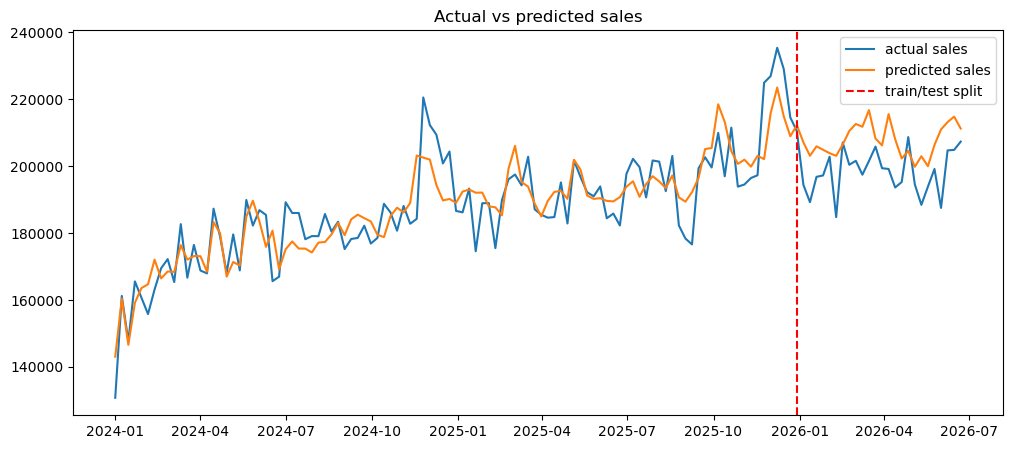

In [26]:
df["all_predictions"] = ridge_final.predict(X_v3)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(df["week"], df["sales"], label="actual sales")
plt.plot(df["week"], df["all_predictions"], label="predicted sales")
plt.axvline(df["week"].iloc[train_size], color="red", linestyle="--", label="train/test split")
plt.legend()
plt.title("Actual vs predicted sales")
plt.show()

In [27]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

train_mae = mean_absolute_error(y_train, train_predictions)
test_mae = mean_absolute_error(y_test, test_predictions)
train_mape = mean_absolute_percentage_error(y_train, train_predictions)
test_mape = mean_absolute_percentage_error(y_test, test_predictions)

print(f"Train MAE: ${train_mae:,.0f}  |  Train MAPE: {train_mape:.1%}")
print(f"Test MAE:  ${test_mae:,.0f}  |  Test MAPE:  {test_mape:.1%}")

Train MAE: $6,235  |  Train MAPE: 3.3%
Test MAE:  $9,458  |  Test MAPE:  4.8%


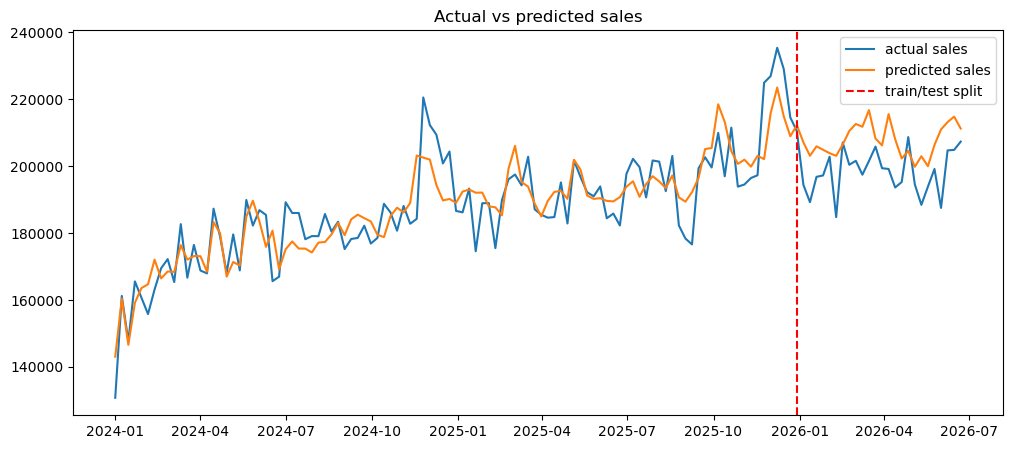

In [28]:
plt.figure(figsize=(12, 5))
plt.plot(df["week"], df["sales"], label="actual sales")
plt.plot(df["week"], df["all_predictions"], label="predicted sales")
plt.axvline(df["week"].iloc[train_size], color="red", linestyle="--", label="train/test split")
plt.legend()
plt.title("Actual vs predicted sales")
plt.savefig("../actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

In [30]:
export_df = df[["week", "sales", "all_predictions", "tv_spend", "search_spend", "social_spend", "email_spend", "promo_flag"]].copy()
export_df["tv_est_contribution"] = df["tv_est_v3"]
export_df["search_est_contribution"] = df["search_est_v3"]
export_df["social_est_contribution"] = df["social_est_v3"]
export_df["email_est_contribution"] = df["email_est_v3"]

export_df.to_csv("../Data/mmm_dashboard_data.csv", index=False)
print("Exported:", export_df.shape)

Exported: (130, 12)


In [31]:
final_comparison = pd.DataFrame({
    "channel": ["TV", "Search", "Social", "Email"],
    "model_estimate": [
        df["tv_est_v3"].mean(),
        df["search_est_v3"].mean(),
        df["social_est_v3"].mean(),
        df["email_est_v3"].mean(),
    ],
    "true_value": [
        ground_truth["tv_contribution"].mean(),
        ground_truth["search_contribution"].mean(),
        ground_truth["social_contribution"].mean(),
        ground_truth["email_contribution"].mean(),
    ],
})

final_comparison.to_csv("../Data/mmm_ground_truth_comparison.csv", index=False)
final_comparison

,channel,model_estimate,true_value
0,TV,17276.536430,39528.000000
1,Search,22182.107026,23741.407692
2,Social,38755.361309,23184.700000
3,Email,5027.279808,4650.830769
